# **PROYECTO 2 - MODELO DE REGRESIÓN**
## Predicción del Puntaje Global Saber 11 - Departamento del Huila

**Pregunta de negocio:** ¿Cuál es el puntaje global esperado de un estudiante dado su estrato, zona (urbano/rural), educación de padres y jornada?

**Responsable:** Juan Nicolás Hidalgo Parra  

**Rol:** Ciencia de Datos / Tablero de datos

**Tipo de modelo:** Regresión con Red Neuronal (Keras/TensorFlow)

## 1. LIBRERÍAS Y CARGA DE DATOS

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

import mlflow
import mlflow.keras

import warnings

In [ ]:
# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Carga del dataset depurado del Huila
df = pd.read_csv('../tarea2_datos/Datos_Huila_Limpio.csv')

print(f"Shape del dataset: {df.shape}")
df.head()

Shape del dataset: (111556, 19)


,periodo,municipio,naturaleza_colegio,area_colegio,jornada,calendario,enfoque_colegio,genero,estrato,educacion_madre,educacion_padre,tiene_internet,tiene_computador,puntaje_matematicas,puntaje_lectura,puntaje_sociales,puntaje_ciencias,puntaje_ingles,puntaje_global
0,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0
1,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0
2,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0
3,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0
4,20152,ALGECIRAS,OFICIAL,URBANO,SABATINA,A,ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,44.0,46.0,49.0,43.0,52.0,230.0


## 2. SELECCIÓN Y PREPROCESAMIENTO DE VARIABLES

Se seleccionan las variables predictoras relevantes para responder la pregunta de negocio. 

**Importante:** los puntajes por materia (matemáticas, lectura, ciencias, sociales, inglés) se excluyen porque son componentes directos del puntaje global — incluirlos generaría *data leakage*.

In [ ]:
# Variables seleccionadas
features = [
    'estrato',
    'area_colegio',
    'educacion_madre',
    'educacion_padre',
    'jornada',
    'municipio',
    'tiene_internet',
    'tiene_computador',
    'naturaleza_colegio',
    'genero'
]

target = 'puntaje_global'

df_model = df[features + [target]].dropna()
print(f"Registros tras eliminar nulos: {len(df_model)}")
print(f"\nDistribución del target:")
print(df_model[target].describe())

Registros tras eliminar nulos: 105542

Distribución del target:
count    105542.000000
mean        253.554793
std          47.731921
min          81.000000
25%         218.000000
50%         250.000000
75%         285.000000
max         469.000000
Name: puntaje_global, dtype: float64


### 2.1 Codificación de Variables Categóricas

Se aplican distintas estrategias según el tipo de variable:
- **Variables ordinales** (estrato, educación padres): codificación numérica respetando el orden
- **Variables binarias** (zona, internet, computador, género): codificación 0/1
- **Variables nominales** (jornada, naturaleza): one-hot encoding
- **Municipio**: target encoding (promedio del puntaje global por municipio)

In [ ]:
df_enc = df_model.copy()

# --- 1. Estrato: ordinal ---
estrato_map = {
    'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
    'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6,
    'Sin Estrato': 0
}
df_enc['estrato'] = df_enc['estrato'].map(estrato_map)

# --- 2. Educación padres: ordinal ---
# Cubre AMBAS versiones de etiquetas que aparecen en el dataset
edu_map = {
    'Ninguno': 0,
    'Primaria incompleta': 1,
    'Primaria completa': 2,
    'Secundaria incompleta': 3,
    'Secundaria (Bachillerato) incompleta': 3,
    'Secundaria completa': 4,
    'Secundaria (Bachillerato) completa': 4,
    'Técnica o tecnológica incompleta': 5,
    'Técnica o tecnológica completa': 6,
    'Educación profesional incompleta': 7,
    'Educación profesional completa': 8,
    'Postgrado': 9
}
df_enc['educacion_madre'] = df_enc['educacion_madre'].map(edu_map)
df_enc['educacion_padre'] = df_enc['educacion_padre'].map(edu_map)

# --- 3. Variables binarias ---
df_enc['area_colegio']       = (df_enc['area_colegio'] == 'URBANO').astype(int)
df_enc['tiene_internet']     = (df_enc['tiene_internet'] == 'Si').astype(int)
df_enc['tiene_computador']   = (df_enc['tiene_computador'] == 'Si').astype(int)
df_enc['genero']             = (df_enc['genero'] == 'M').astype(int)
df_enc['naturaleza_colegio'] = (df_enc['naturaleza_colegio'] == 'NO OFICIAL').astype(int)

# --- 4. Municipio: target encoding ---
mun_target_enc = df_enc.groupby('municipio')[target].mean()
df_enc['municipio'] = df_enc['municipio'].map(mun_target_enc)

# --- 5. Jornada: one-hot encoding ---
df_enc = pd.get_dummies(df_enc, columns=['jornada'], prefix='jornada', drop_first=True)

# --- DIAGNÓSTICO: verificar NaN antes de continuar ---
nulos = df_enc.isnull().sum()
print("NaN por columna:")
print(nulos[nulos > 0])

# Eliminar filas con NaN residuales
df_enc = df_enc.dropna()
print(f"\nRegistros finales tras limpiar NaN residuales: {len(df_enc)}")

print("\nVariables finales del modelo:")
print(df_enc.drop(columns=[target]).columns.tolist())
print(f"Total features: {df_enc.shape[1] - 1}")

NaN por columna:
educacion_madre    1560
educacion_padre    4607
dtype: int64

Registros finales tras limpiar NaN residuales: 100360

Variables finales del modelo:
['estrato', 'area_colegio', 'educacion_madre', 'educacion_padre', 'municipio', 'tiene_internet', 'tiene_computador', 'naturaleza_colegio', 'genero', 'jornada_MAÑANA', 'jornada_NOCHE', 'jornada_SABATINA', 'jornada_TARDE', 'jornada_UNICA']
Total features: 14


## 3. DIVISIÓN Y ESCALAMIENTO DE DATOS

In [ ]:
X = df_enc.drop(columns=[target]).values
y = df_enc[target].values

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalamiento de features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Escalamiento del target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"y_train — media: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"y_train_scaled — media: {y_train_scaled.mean():.2f}, std: {y_train_scaled.std():.2f}")

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba:        {X_test.shape}")

y_train — media: 253.28, std: 47.58
y_train_scaled — media: 0.00, std: 1.00
Tamaño entrenamiento: (80288, 14)
Tamaño prueba:        (20072, 14)


## 4. MODELO BASE DE REGRESIÓN

**Arquitectura:** Red neuronal con capas densas y activación ReLU en capas ocultas. La capa de salida usa activación lineal (sin activación), apropiada para regresión. La función de pérdida es MSE (Mean Squared Error).

In [ ]:
n_features = X_train.shape[1]

def build_model_base():
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)  # Salida lineal para regresión
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='mse',
        metrics=['mae']
    )
    return model

model_base = build_model_base()
model_base.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 2.4693 - mae: 1.2591 - val_loss: 1.2247 - val_mae: 0.8899
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.9524 - mae: 0.7813 - val_loss: 0.7899 - val_mae: 0.7132
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7533 - mae: 0.6963 - val_loss: 0.7301 - val_mae: 0.6856
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7290 - mae: 0.6848 - val_loss: 0.7242 - val_mae: 0.6828
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7263 - mae: 0.6834 - val_loss: 0.7236 - val_mae: 0.6824
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7258 - mae: 0.6831 - val_loss: 0.7236 - val_mae: 0.6824
Epoch 7/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7257 - mae: 0.6831 - val_loss: 0.7239 - val_mae: 0.6825
Epoch 8/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7258 - mae: 0.6831 - val_loss: 0.7240 - val_mae: 0.6825
Epoch 9/100
314/314 ━━━━━━━━━━━━━━━━━━━━

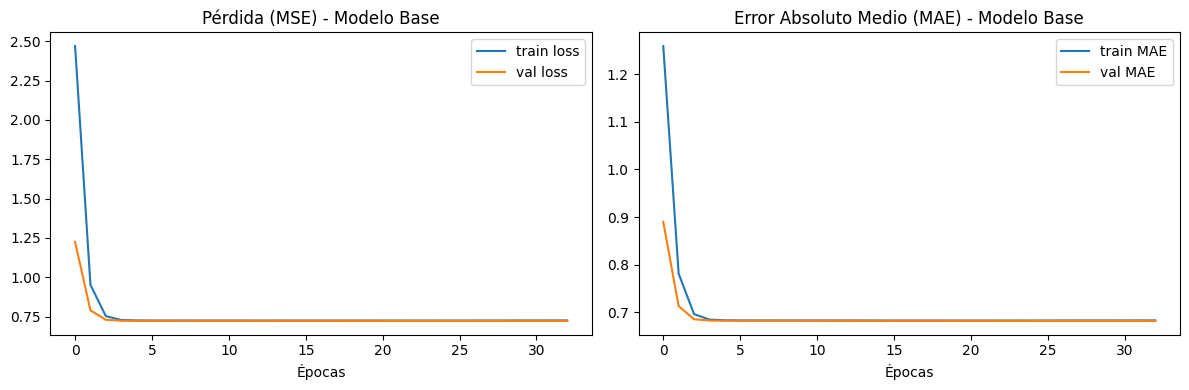

In [ ]:
# Callback de early stopping para evitar sobreajuste
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1  
)

history_base = model_base.fit(
    X_train, y_train_scaled,        
    validation_data=(X_test, y_test_scaled),
    epochs=100,                     
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nÉpocas entrenadas: {len(history_base.history['loss'])}")

# Visualización de pérdida
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_base.history['loss'], label='train loss')
ax1.plot(history_base.history['val_loss'], label='val loss')
ax1.set_title('Pérdida (MSE) - Modelo Base')
ax1.set_xlabel('Épocas')
ax1.legend()

ax2.plot(history_base.history['mae'], label='train MAE')
ax2.plot(history_base.history['val_mae'], label='val MAE')
ax2.set_title('Error Absoluto Medio (MAE) - Modelo Base')
ax2.set_xlabel('Épocas')
ax2.legend()

plt.tight_layout()
plt.show()

### 4.1 Métricas de Evaluación

In [ ]:
def evaluar_modelo(model, X_test, y_test_scaled, y_test_real, nombre='Modelo'):
    # Predice en escala normalizada y devuelve a escala original
    y_pred_scaled = model.predict(X_test).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
    mae  = mean_absolute_error(y_test_real, y_pred)
    r2   = r2_score(y_test_real, y_pred)

    print(f"--- MÉTRICAS {nombre} ---")
    print(f"RMSE: {rmse:.4f}  (puntos del puntaje global)")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    return {'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Reiniciar results_all con las métricas correctas del modelo base
metricas_base = evaluar_modelo(model_base, X_test, y_test_scaled, y_test, 'Base')
results_all = [metricas_base]

628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- MÉTRICAS Base ---
RMSE: 40.4444  (puntos del puntaje global)
MAE:  32.4444
R²:   0.2748


628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


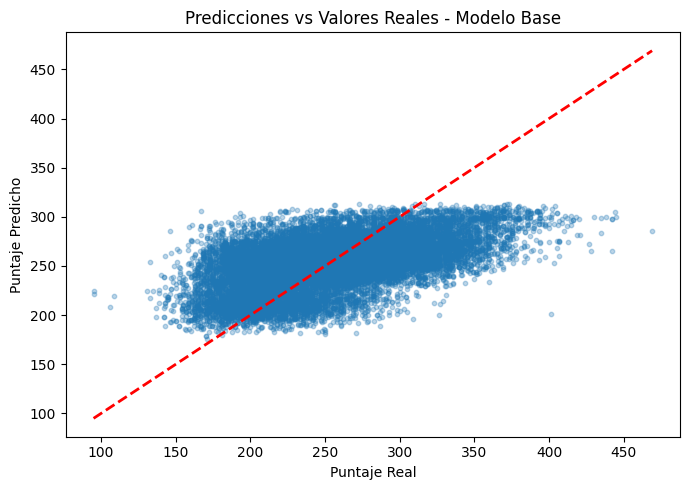

In [ ]:
# Gráfica predicciones vs valores reales
y_pred_scaled = model_base.predict(X_test).flatten()
y_pred_base = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_base, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Puntaje Real')
plt.ylabel('Puntaje Predicho')
plt.title('Predicciones vs Valores Reales - Modelo Base')
plt.tight_layout()
plt.show()

**ANÁLISIS:** [Completar con los resultados reales al ejecutar el notebook]

El RMSE indica el error promedio en puntos del puntaje global. Un R² cercano a 1 indica que el modelo explica bien la variabilidad del puntaje. Se espera que variables como estrato, zona y educación de padres tengan mayor peso predictivo, coherente con los hallazgos del Proyecto 1.

## 5. EXPERIMENTACIÓN CON VARIACIONES DE LA RED

Se exploran 3 configuraciones diferentes para identificar la arquitectura más adecuada.

In [ ]:
# ============================================================
# SECCIÓN 5 - EXPERIMENTACIÓN CON VARIACIONES DE LA RED
# ============================================================

from tensorflow.keras.layers import Dense, Dropout, Input

# --- MODELO 1: Red más profunda ---
def build_model_1():
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(32,  activation='relu'),
        Dense(16,  activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
    return model

# --- MODELO 2: Red con Dropout para regularización ---
def build_model_2():
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(64,  activation='relu'),
        Dropout(0.3),
        Dense(32,  activation='relu'),
        Dropout(0.3),
        Dense(16,  activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
    return model

# --- MODELO 3: Red simple con tasa de aprendizaje mayor ---
def build_model_3():
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Entrenamiento y evaluación de las 3 variaciones
results_all = [metricas_base]
histories = {}

configs = [
    (build_model_1, 'Modelo 1 - Red Profunda'),
    (build_model_2, 'Modelo 2 - Con Dropout'),
    (build_model_3, 'Modelo 3 - Simple + LR alto'),
]

for build_fn, nombre in configs:
    print(f"\nEntrenando {nombre}...")
    m = build_fn()
    h = m.fit(
        X_train, y_train_scaled,
        validation_data=(X_test, y_test_scaled),
        epochs=100,
        batch_size=256,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    histories[nombre] = h
    metricas = evaluar_modelo(m, X_test, y_test_scaled, y_test, nombre)
    results_all.append(metricas)


Entrenando Modelo 1 - Red Profunda...
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- MÉTRICAS Modelo 1 - Red Profunda ---
RMSE: 40.5046  (puntos del puntaje global)
MAE:  32.4910
R²:   0.2726

Entrenando Modelo 2 - Con Dropout...
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- MÉTRICAS Modelo 2 - Con Dropout ---
RMSE: 40.7740  (puntos del puntaje global)
MAE:  32.7482
R²:   0.2629

Entrenando Modelo 3 - Simple + LR alto...
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- MÉTRICAS Modelo 3 - Simple + LR alto ---
RMSE: 40.4881  (puntos del puntaje global)
MAE:  32.4504
R²:   0.2732


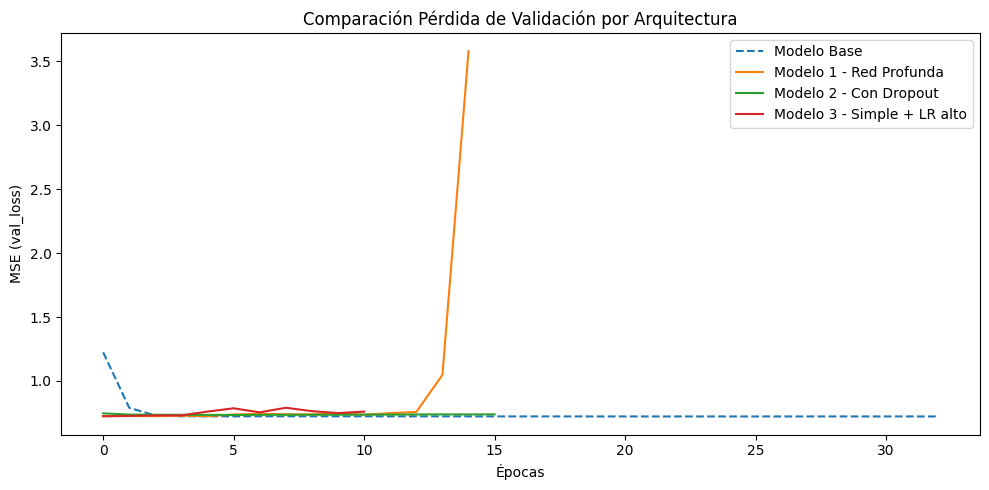

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_base.history['val_loss'], label='Modelo Base', linestyle='--')
for nombre, h in histories.items():
    plt.plot(h.history['val_loss'], label=nombre)
plt.title('Comparación Pérdida de Validación por Arquitectura')
plt.xlabel('Épocas')
plt.ylabel('MSE (val_loss)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Tabla comparativa
df_results = pd.DataFrame(results_all)
df_results

,Modelo,RMSE,MAE,R²
0,Base,40.444412,32.444435,0.274760
1,Modelo 1 - Red Profunda,40.504602,32.491046,0.272600
2,Modelo 2 - Con Dropout,40.773995,32.748194,0.262892
3,Modelo 3 - Simple + LR alto,40.488095,32.450385,0.273193


**ANÁLISIS:** [Completar con los resultados reales al ejecutar]

Se comparan las cuatro configuraciones en términos de RMSE, MAE y R². El modelo con menor RMSE y mayor R² será el seleccionado para el tablero.

## 6. REGISTRO DE EXPERIMENTOS CON MLFLOW

In [ ]:
mlflow.set_tracking_uri("./mlruns")  # guarda en la misma carpeta del notebook
mlflow.set_experiment("Regresion_PuntajeGlobal_Huila")

configs_mlflow = [
    {'nombre': 'Modelo_Base',      'build_fn': build_model_base, 'lr': 0.0001, 'dropout': False},
    {'nombre': 'Modelo_Profundo',  'build_fn': build_model_1,    'lr': 0.0001, 'dropout': False},
    {'nombre': 'Modelo_Dropout',   'build_fn': build_model_2,    'lr': 0.0001, 'dropout': True},
    {'nombre': 'Modelo_Simple_LR', 'build_fn': build_model_3,    'lr': 0.001,  'dropout': False},
]

for cfg in configs_mlflow:
    with mlflow.start_run(run_name=cfg['nombre']):
        mlflow.log_param('learning_rate', cfg['lr'])
        mlflow.log_param('dropout',       cfg['dropout'])
        mlflow.log_param('batch_size',    256)
        mlflow.log_param('epochs_max',    100)
        mlflow.log_param('optimizer',     'Adam')

        m = cfg['build_fn']()
        m.fit(
            X_train, y_train_scaled,                       # ← target escalado
            validation_data=(X_test, y_test_scaled),
            epochs=100,
            batch_size=256,                                # ← rápido
            callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
            verbose=0
        )

        # Métricas en escala real
        y_pred_scaled = m.predict(X_test).flatten()
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        mlflow.log_metric('RMSE', rmse)
        mlflow.log_metric('MAE',  mae)
        mlflow.log_metric('R2',   r2)
        mlflow.keras.log_model(m, artifact_path='model')

        print(f"{cfg['nombre']} — RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

print("\nExperimentos registrados en MLflow.")

628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


2026/05/21 00:15:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 00:15:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Base — RMSE: 40.4510 | MAE: 32.4472 | R²: 0.2745
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


2026/05/21 00:16:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 00:16:24 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Profundo — RMSE: 40.4836 | MAE: 32.4809 | R²: 0.2734
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


2026/05/21 00:18:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 00:18:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Dropout — RMSE: 40.8198 | MAE: 32.8071 | R²: 0.2612
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


2026/05/21 00:19:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 00:19:05 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Simple_LR — RMSE: 40.4912 | MAE: 32.4622 | R²: 0.2731

Experimentos registrados en MLflow.


## 7. MODELO FINAL: SERIALIZACIÓN

Se selecciona el mejor modelo según las métricas y se serializa para su uso en el tablero Dash.

In [ ]:
import joblib
import os

mejor_modelo = build_model_base()  # Ajustar según el mejor de la tabla

mejor_modelo.fit(
    X_train, y_train_scaled,
    validation_data=(X_test, y_test_scaled),
    epochs=100,
    batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

os.makedirs('../tarea5_tablero/modelos', exist_ok=True)

# Formato .keras en lugar de .h5
mejor_modelo.save('../tarea5_tablero/modelos/modelo_regresion.keras')
joblib.dump(scaler_X, '../tarea5_tablero/modelos/scaler_X_regresion.pkl')
joblib.dump(scaler_y, '../tarea5_tablero/modelos/scaler_y_regresion.pkl')
joblib.dump(mun_target_enc.to_dict(), '../tarea5_tablero/modelos/municipio_encoder.pkl')

print("Modelo, scalers y encoders guardados correctamente.")

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.1390 - mae: 0.8547 - val_loss: 0.8215 - val_mae: 0.7288
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7664 - mae: 0.7028 - val_loss: 0.7377 - val_mae: 0.6890
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7325 - mae: 0.6862 - val_loss: 0.7270 - val_mae: 0.6836
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7274 - mae: 0.6835 - val_loss: 0.7250 - val_mae: 0.6826
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7265 - mae: 0.6831 - val_loss: 0.7246 - val_mae: 0.6824
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7264 - mae: 0.6830 - val_loss: 0.7246 - val_mae: 0.6824
Epoch 7/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7264 - mae: 0.6831 - val_loss: 0.7246 - val_mae: 0.6825
Epoch 8/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7264 - mae: 0.6831 - val_loss: 0.7247 - val_mae: 0.6826
Epoch 9/100
314/314 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import load_model

modelo_cargado  = load_model('../tarea5_tablero/modelos/modelo_regresion.keras')
scaler_y_cargado = joblib.load('../tarea5_tablero/modelos/scaler_y_regresion.pkl')

y_pred_scaled = modelo_cargado.predict(X_test[:5]).flatten()
y_pred_check  = scaler_y_cargado.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

print("Predicciones de verificación:", y_pred_check.round(1))
print("Valores reales:               ", y_test[:5].round(1))
print("\nModelo cargado correctamente ✓")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
Predicciones de verificación: [212.  239.3 275.  261.3 301.5]
Valores reales:                [180. 266. 311. 274. 360.]

Modelo cargado correctamente ✓


## 8. CONCLUSIONES

**[Completar con los resultados reales tras ejecutar el notebook]**

1. **Mejor modelo:** Indicar cuál configuración obtuvo el menor RMSE y mayor R².
2. **Variables más influyentes:** Estrato, zona y educación de padres son los predictores esperados con mayor peso, coherente con los hallazgos del Proyecto 1.
3. **Limitaciones:** El modelo predice el puntaje esperado dado el perfil socioeconómico, pero no captura esfuerzo individual ni calidad docente.
4. **Utilidad para la Secretaría:** Permite simular el impacto de mejorar condiciones (ej: pasar de zona rural a urbana) sobre el puntaje esperado de un estudiante con un perfil dado.